In [1]:
'''libraries'''
#Data
import pandas as pd

#Plots
import matplotlib.pyplot as plt

#fits
#from scipy.optimize import curve_fit

#math
import numpy as np
import scipy.integrate as integrate


#Constants
from scipy.constants import physical_constants
m_u=physical_constants['atomic mass constant energy equivalent in MeV'][0]
from scipy.constants import speed_of_light as c

#Usefull
from tqdm.notebook import tqdm
import os
from scipy.interpolate import interp1d
import pynucastro as pyna
#%matplotlib widget

In [2]:

def dudt_funtion_of_E_t(ta, u, b, tc, E__, time):
    
    time = np.asarray(time)
    E__  = np.asarray(E__)

    x = ta * tc
    idx = np.searchsorted(time, x, side="left")

    if idx <= 0:
        E_val = E__[0]
    elif idx >= len(E__):
        E_val = E__[-1]
    else:
        E_val = E__[idx]

    if ta <= 1:
        return (E_val)/(ta**3) - u*((4/ta) + 3*ta/(4*b))
    else:
        return (E_val)/(ta**3) - u*((4/ta) + 3*ta/(4*b))#(E_val)/(ta**3) - (u/ta)*(4 + 3/(4*b))


def solucionar(U_0,tau_n,b,tc,n,E__,time):
    U_n=np.zeros(n)
    U_n[0]=U_0
    
    h=tau_n[1]-tau_n[0]
    for i in range(len(U_n)):
    
        k1=h*dudt_funtion_of_E_t(tau_n[i],U_n[i],b,tc,E__,time)
        k2=h*dudt_funtion_of_E_t(tau_n[i]+h/2,U_n[i]+k1/2,b,tc,E__,time)
        k3=h*dudt_funtion_of_E_t(tau_n[i]+h/2,U_n[i]+k2/2,b,tc,E__,time)
        k4=h*dudt_funtion_of_E_t(tau_n[i]+h,U_n[i]+k3,b,tc,E__,time)
        if i!=len(U_n)-1:
            U_n[i+1]=U_n[i]+(1/6)*(k1+2*k2+2*k3+k4)
    return U_n

def termalizacion(time,Mey,Vey,E):
   

    tb=12.9*((Mey/0.01)**(2/3))*((Vey/0.2)**(-2))*24*60*60 #termalization beta particles
    ty=0.3*np.sqrt(Mey/0.01)*(0.2/Vey)*24*60*60 ##termalization gamma particles
    f_gamma=1-np.exp(-(ty/time)**2)
    f_electrons=(1+time/tb)**(-1)
    f_beta=0.2*f_electrons+0.5*f_gamma
    return E*f_beta*0.8

def generar_Luminosidad(M,k,b,U_0,tau_0,tau_f,n,E_,time):
    E_=termalizacion(time,M,b,E_)
    M=M*(1.989*10**30)#kg
    tc=np.sqrt(3*k*M/(4*np.pi*(b*c)**2))
    Tau_n=np.linspace(tau_0,tau_f,n)
    Uo=solucionar(U_0,Tau_n,b,tc,n,E_,time)
    te=tc*Tau_n
    tedias=te*(1/(60*60*24))
    U=((3*M)/(4*np.pi*((b*c)**3)*((tc)**(2))))*Uo
    L=np.zeros(len(U))
    L=((np.pi*((b*c)**2)*c)*(te**4)/(tc**2))*U*10**7
    
    return [L,tedias]

In [3]:
'''
Run_1 = pd.read_csv("Runs/Run_1/generated_energy.dat",sep="\s{2,}",skiprows=2,header=None, engine='python')
Run_2=pd.read_csv("Runs/Run_2/generated_energy.dat",sep='\s{2,}',skiprows=2,header=None, engine= 'python')

Run_Tian_NMHF=pd.read_csv("Runs/Run_Tian_NMHF/generated_energy.dat",sep='\s{2,}',skiprows=2,header=None, engine= 'python')
Run_Tian_NMHF_3=pd.read_csv("Runs/Run_Tian_NMHF_3/generated_energy.dat",sep='\s{2,}',skiprows=2,header=None, engine= 'python')
Run_Tian_SONG=pd.read_csv("Runs/Run_Tian_SONG/generated_energy.dat",sep='\s{2,}',skiprows=2,header=None, engine= 'python')

Run_Zhou_NMHF=pd.read_csv("Runs/Run_Zhou_NMHF/generated_energy.dat",sep='\s{2,}',skiprows=2,header=None, engine= 'python')
Run_Zhou_NMHF_3=pd.read_csv("Runs/Run_Zhou_NMHF_3/generated_energy.dat",sep='\s{2,}',skiprows=2,header=None, engine= 'python')
Run_Zhou_SONG=pd.read_csv("Runs/Run_Zhou_SONG/generated_energy.dat",sep='\s{2,}',skiprows=2,header=None, engine= 'python')
'''
initial_time=1.0006912859 #seconds
final_time=4.32E7 #seconds 500 days= 4.32E7 seconds 100 days= 8.64E7 seconds
N_steps=10000
time = np.exp(np.linspace(np.log(initial_time), np.log(final_time), N_steps))
time_days=time/(24*60*60)
E_I=[]
approach_I='epsilon_calculations/approach_I/'
results=['/a_top', '/b_top']
#Jina reaclib, Exp reaclib, Tian, Tian NMHF, Tian NMHF 3, Tian song, Tian song 3, Zhou NMHF, Zhou NMHF 3, Zhou SONG
runs_I=['Run_1', 'Run_2', 'Run_3', 'Run_4','Run_4_3', 'Run_5','Run_5_3','Run_10', 'Run_10_3', 'Run_11']

for run in runs_I:
    file_a=approach_I+run+'/Alpha.csv'
    file_b=approach_I+run+'/Beta_minus.csv'
    E_I.append(pd.read_csv(file_a,sep=',',skiprows=1,header=None)[1].values+pd.read_csv(file_b,sep=',',skiprows=1,header=None)[1].values)
Run_1=[time,E_I[0]]
Run_2=[time,E_I[1]]

Run_Tian_NMHF=[time,E_I[3]]
Run_Tian_NMHF_3=[time,E_I[4]]
Run_Tian_SONG=[time,E_I[5]]
Run_Tian_SONG_3=[time,E_I[6]]

Run_Zhou_NMHF=[time,E_I[7]]
Run_Zhou_NMHF_3=[time,E_I[8]]
Run_Zhou_SONG=[time,E_I[9]]

In [4]:
#Light curves

L_1=generar_Luminosidad(0.05,0.02,0.2,10**10,0.001,85,100000,Run_1[1]*1e-4,Run_1[0])
L_2=generar_Luminosidad(0.05,0.02,0.2,10**10,0.001,85,100000,Run_2[1]*1e-4,Run_2[0])

L_Tian_NMHF=generar_Luminosidad(0.05,0.02,0.2,10**10,0.001,85,100000,Run_Tian_NMHF[1]*1e-4,Run_Tian_NMHF[0])
L_Tian_NMHF_3=generar_Luminosidad(0.05,0.02,0.2,10**10,0.001,85,100000,Run_Tian_NMHF_3[1]*1e-4,Run_Tian_NMHF_3[0])
L_Tian_SONG=generar_Luminosidad(0.05,0.02,0.2,10**10,0.001,85,100000,Run_Tian_SONG[1]*1e-4,Run_Tian_SONG[0])

L_Zhou_NMHF=generar_Luminosidad(0.05,0.02,0.2,10**10,0.001,85,100000,Run_Zhou_NMHF[1]*1e-4,Run_Zhou_NMHF[0])
L_Zhou_NMHF_3=generar_Luminosidad(0.05,0.02,0.2,10**10,0.001,85,100000,Run_Zhou_NMHF_3[1]*1e-4,Run_Zhou_NMHF_3[0])
L_Zhou_SONG=generar_Luminosidad(0.05,0.02,0.2,10**10,0.001,85,100000,Run_Zhou_SONG[1]*1e-4,Run_Zhou_SONG[0])

In [5]:
#observaciones

L_AT2017gfo= pd.read_csv("observations/AT2017gfo.csv",sep=';',skiprows=0,header=None, engine= 'python')
L_AT2017gfo[1] = L_AT2017gfo[1].str.replace(",", ".", regex=False).astype(float)
L_AT2017gfo[0] = L_AT2017gfo[0].str.replace(",", ".", regex=False).astype(float)
L_error_AT2017gfo= pd.read_csv("observations/AT2017_E.csv",sep=';',skiprows=0,header=None, engine= 'python')
L_error_AT2017gfo[0] = L_error_AT2017gfo[0].str.replace(",", ".", regex=False).astype(float)
L_error_AT2017gfo[1] = L_error_AT2017gfo[1].str.replace(",", ".", regex=False).astype(float)
L_error_AT2017gfo[2] = L_error_AT2017gfo[2].str.replace(",", ".", regex=False).astype(float)
L_error_AT2017gfo[3] = L_error_AT2017gfo[3].str.replace(",", ".", regex=False).astype(float)
ye=10**(L_error_AT2017gfo[1])*(L_error_AT2017gfo[2]-L_error_AT2017gfo[3])/(0.5*np.log(10))

L_AT2023vfi= pd.read_csv("observations/AT2023vfi.csv",sep=';',skiprows=0,header=None, engine= 'python')
L_AT2023vfi[1] = L_AT2023vfi[1].str.replace(",", ".", regex=False).astype(float)
L_AT2023vfi[0] = L_AT2023vfi[0].str.replace(",", ".", regex=False).astype(float)
L_error_AT2023vfi= pd.read_csv("observations/AT2023vfi_E.csv",sep=';',skiprows=0,header=None, engine= 'python')
L_error_AT2023vfi[0] = L_error_AT2023vfi[0].str.replace(",", ".", regex=False).astype(float)
L_error_AT2023vfi[1] = L_error_AT2023vfi[1].str.replace(",", ".", regex=False).astype(float)
L_error_AT2023vfi[2] = L_error_AT2023vfi[2].str.replace(",", ".", regex=False).astype(float)
L_error_AT2023vfi[3] = L_error_AT2023vfi[3].str.replace(",", ".", regex=False).astype(float)
ye2=10**(L_error_AT2023vfi[1])*(L_error_AT2023vfi[2]-L_error_AT2023vfi[3])/(0.5*np.log(10))


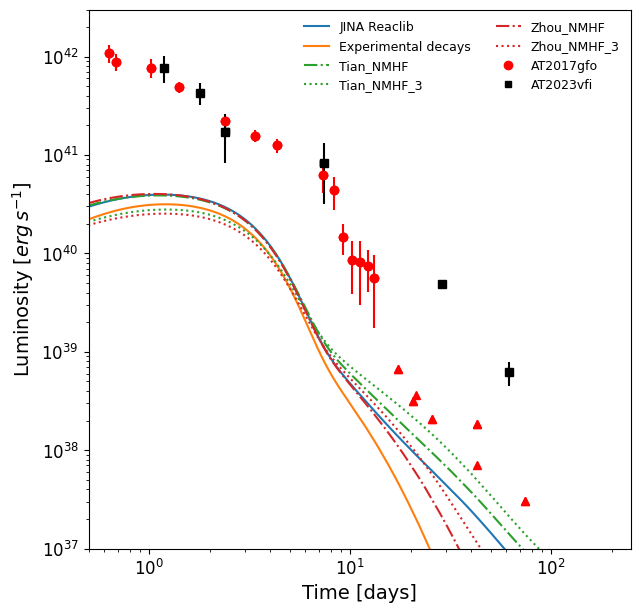

In [6]:
plt.figure(figsize=(7,7))
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})
plt.plot(L_1[1],L_1[0],label="JINA Reaclib")
plt.plot(L_2[1],L_2[0],label="Experimental decays")

plt.plot(L_Tian_NMHF[1],L_Tian_NMHF[0],label=r"Tian_NMHF",linestyle='-.',color='C2')
plt.plot(L_Tian_NMHF_3[1],L_Tian_NMHF_3[0],label=r"Tian_NMHF_3",linestyle=':',color='C2')
#plt.plot(L_Tian_SONG[1],L_Tian_SONG[0],label=r"Tian_SONG",linestyle='-.')

plt.plot(L_Zhou_NMHF[1],L_Zhou_NMHF[0],label=r"Zhou_NMHF",linestyle='-.',color='C3')
plt.plot(L_Zhou_NMHF_3[1],L_Zhou_NMHF_3[0],label=r"Zhou_NMHF_3",linestyle=':',color='C3')
#plt.plot(L_Zhou_SONG[1],L_Zhou_SONG[0],label=r"Zhou_SONG",linestyle='-.')

plt.plot(L_error_AT2017gfo[0],10**(L_error_AT2017gfo[1]), 'o', label='AT2017gfo', color='red')
plt.errorbar(L_error_AT2017gfo[0],10**(L_error_AT2017gfo[1]), yerr=ye, fmt='o', color='red')
plt.plot(L_AT2017gfo[0][20:],10**(L_AT2017gfo[1][20:]), '^', color='red')
plt.plot(L_AT2023vfi[0],10**(L_AT2023vfi[1]), 's', label='AT2023vfi', markersize=4,color='black')
plt.errorbar(L_error_AT2023vfi[0],10**(L_error_AT2023vfi[1]), yerr=ye2, fmt='s', color='black')


plt.xlabel("Time [days]")
plt.ylabel(r"Luminosity $[erg\,s^{-1}]$")
plt.yscale("log")
plt.xscale("log")
plt.ylim(1e37,3e42)
plt.xlim(0.5,250)
plt.legend(loc="upper right", ncol=2,frameon=False,fontsize=9)
plt.savefig("Figure_5_Luminosity_I.pdf",dpi=1200)